# Auto Scout Project

**Author:** Mark Joslin

**GitHub:** [link](https://github.com/mjoslin-ai/Magnimind-Project-Auto-Scout)

## Table of Contents

* Objective
* Libraries
* CPU Cores
* Helper Functions
* Import Data
* All Features
* Reduced Features
* Export Final Model

## Objective

The objective of this notebook is to build, tune, evaluate, and compare machine learning regression models to **predict the price** of used cars in the Auto Scout dataset.

Using the fully cleaned, preprocessed, and feature-engineered dataset produced in the previous stages (data cleaning, missing value analysis, outlier handling, and dummy variable generation), we now have a structured numeric dataset containing **15,918 rows and 138 columns**, with all features converted to `float` or `integer` types — fully compatible with machine learning algorithms.

In this notebook, we test several regression models with Optuna hyperparameter tuning, select the best performing model, analyze variable importance, and retrain the top model on a reduced feature set to improve interpretability and computational efficiency.

This notebook completes the end-to-end Auto Scout project workflow, from raw, inconsistent data to a production ready predictive model capable of accurately estimating car prices based on vehicle characteristics.

## Libraries

In [2]:
# Standard Library
import os

# Data Science & Visualization
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import shap

# System / Utilities
import psutil
import joblib
import pickle

# Scikit-learn
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import  StandardScaler

# Advanced ML Frameworks & Hyperparameter Optimization
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
import optuna
from xgboost import XGBRegressor

c:\Users\Mark\Documents\magnimind\Auto-Scout-Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## CPU Cores

In [3]:
logical_cores = psutil.cpu_count(logical=True)
physical_cores = psutil.cpu_count(logical=False)

print(f"Logical cores: {logical_cores}")
print(f"Physical cores: {physical_cores}")

Logical cores: 16
Physical cores: 8


When creating models, it most efficient to set n_jobs to the number of physical cores, with smaller boost in efficiency up to the number of logical cores.

## Helper Functions

In [4]:
def tune_and_fit_model(pipeline, param_space_fn, X, y, cv=5, n_trials=20, seed=42):
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    model_step_name = pipeline.steps[-1][0]

    def objective(trial):
        params = param_space_fn(trial)
        prefixed_params = {f'{model_step_name}__{k}': v for k, v in params.items()}
        pipeline.set_params(**prefixed_params)
        try:
            return cross_val_score(pipeline, X, y, cv=cv, scoring='r2', n_jobs=physical_cores).mean()
        except Exception as e:
            print(f"Trial {trial.number} failed: {str(e)[:100]}")
            return float("-inf")

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=seed), pruner=optuna.pruners.MedianPruner())
    study.optimize(objective, n_trials=n_trials)

    print(f"Best Validation R2 Score: {study.best_value:.4f}")
    print("\nBest Hyperparameters:")
    for k, v in study.best_params.items():
        print(f"{k}: {round(v, 4) if isinstance(v, (int, float)) else v}")

    # Fit best model
    best_params = {f'{model_step_name}__{k}': v for k, v in study.best_params.items()}
    pipeline.set_params(**best_params).fit(X, y)

    return pipeline, study

In [5]:
def get_model_name(model):
    """
    Helper to extract the class name of the final estimator.
    """
    return type(model._final_estimator).__name__ if hasattr(model, 'steps') else type(model).__name__

In [6]:
def evaluate_model(model, X_train, y_train, X_test, y_test, filepath="model_results.csv", save_model=True, model_dir="saved_models"):
    """
    Evaluate model, log results to CSV, AND optionally save the fitted model as .joblib
    """
    
    name = get_model_name(model)
    num_features = X_train.shape[1]
   
    # Calculate Metrics
    train_r2 = round(r2_score(y_train, model.predict(X_train)), 4)
    test_r2 = round(r2_score(y_test, model.predict(X_test)), 4)
    test_mae = round(mean_absolute_error(y_test, model.predict(X_test)), 4)
    test_rmse = round(root_mean_squared_error(y_test, model.predict(X_test)), 4)
    test_mape = round(mean_absolute_percentage_error(y_test, model.predict(X_test)) * 100, 4)
   
    # Save the model (using joblib)
    if save_model:
        import joblib
        import os
        os.makedirs(model_dir, exist_ok=True)
        model_filename = os.path.join(model_dir, f"{name}_{num_features}_features.joblib")
        joblib.dump(model, model_filename, compress=3)
        print(f"Saved model to {model_filename}")
    
    # Log results to CSV (unchanged)
    new_data = pd.DataFrame([{
        "model": name,
        "features": num_features,
        "train_r2": train_r2,
        "test_r2": test_r2,
        "test_mae": test_mae,
        "test_rmse": test_rmse,
        "test_mape": test_mape
    }])
    
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        df = pd.concat([df, new_data], ignore_index=True)
    else:
        df = new_data
    
    # Keep only the latest entry for a specific model+feature count combo
    df = df.drop_duplicates(subset=['model', 'features'], keep='last')
    df.to_csv(filepath, index=False)
   
    print(f"Logged {name} ({num_features} features) to {filepath}")
    return df

In [7]:
def plot_diagnostics(model, X_test, y_test):
    name = get_model_name(model)
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred
    
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f"Diagnostic Report: {name}", fontsize=16, fontweight='bold')

    # Plot 1: Predicted vs Actual
    sns.scatterplot(x=y_test, y=y_pred, ax=axes[0], alpha=0.5)
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[0].set_title("Predicted vs. Actual")

    # Plot 2: Residuals
    sns.scatterplot(x=y_pred, y=residuals, ax=axes[1], alpha=0.5)
    axes[1].axhline(0, color='r', linestyle='--', lw=2)
    axes[1].set_title("Residuals vs. Predicted")

    plt.tight_layout()
    plt.show()

In [8]:
def model_results(model, X_train, y_train, X_test, y_test, filepath="model_results.csv"):
    """
    One-call solution: plot diagnostics + evaluate + print results
    """
    
    # 1. Show diagnostic plots
    plot_diagnostics(model, X_test, y_test)
    
    # 2. Evaluate and save results
    model_results_df = evaluate_model(model, X_train, y_train, X_test, y_test, filepath)
    
    # 3. Print only this model's row
    name = get_model_name(model)
    print(model_results_df[model_results_df["model"] == name].T)

In [9]:
def get_pipeline_importance(file_path, X_data, feature_names=None):
    """
    Loads a pipeline and calculates feature importance and cumulative importance using SHAP values.
    X_data: The dataset (e.g., X_test) needed to calculate SHAP values.
    """
    try:
        pipeline = joblib.load(file_path)
    except Exception as e:
        return f"Joblib load failed: {e}"
    
    # 1. Extract the fitted regressor
    regressor = pipeline._final_estimator
    
    # 2. Transform the input data using the pipeline's preprocessing steps
    if len(pipeline.steps) > 1:
        X_transformed = pipeline[:-1].transform(X_data)
    else:
        X_transformed = X_data

    try:
        # 3. Initialize SHAP Explainer
        explainer = shap.TreeExplainer(regressor)
        shap_values = explainer.shap_values(X_transformed)

        # 4. Calculate Global Importance (mean absolute SHAP value)
        if isinstance(shap_values, list): 
            mean_shap = np.abs(shap_values[0]).mean(axis=0)
        else:
            mean_shap = np.abs(shap_values).mean(axis=0)

        # 5. Create DataFrame
        if feature_names is None:
            feature_names = X_data.columns if hasattr(X_data, 'columns') else [f"Feature_{i}" for i in range(len(mean_shap))]

        df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': mean_shap
        })

        # 6. Sort by Importance descending
        df = df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

        # 7. Add Cumulative Importance column
        # This calculates the running percentage of total impact
        df['Cumulative_Importance'] = df['Importance'].cumsum() / df['Importance'].sum()

        return df

    except Exception as e:
        return f"SHAP extraction error: {str(e)}"

## Import Data

In [10]:
df_org = pd.read_csv("data/cleaned_data.csv")
df = df_org.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15918 entries, 0 to 15917
Columns: 158 entries, price to entertainment_media_usb
dtypes: float64(17), int64(141)
memory usage: 19.2 MB


## All Features

In [11]:
# Split data
x = df.drop('price', axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### Ordinary Least Squares

In [12]:
ols_pipe = Pipeline([
    ('scaler', StandardScaler()), 
    ('ols', LinearRegression())
])

# No Scaler Tuning
def ols_space(trial):
    return {
        'fit_intercept': trial.suggest_categorical('fit_intercept', [True, False])
    }

ols_model, ols_study = tune_and_fit_model(ols_pipe, ols_space, X_train, y_train)

Best Validation R2 Score: 0.8907

Best Hyperparameters:
fit_intercept: 1


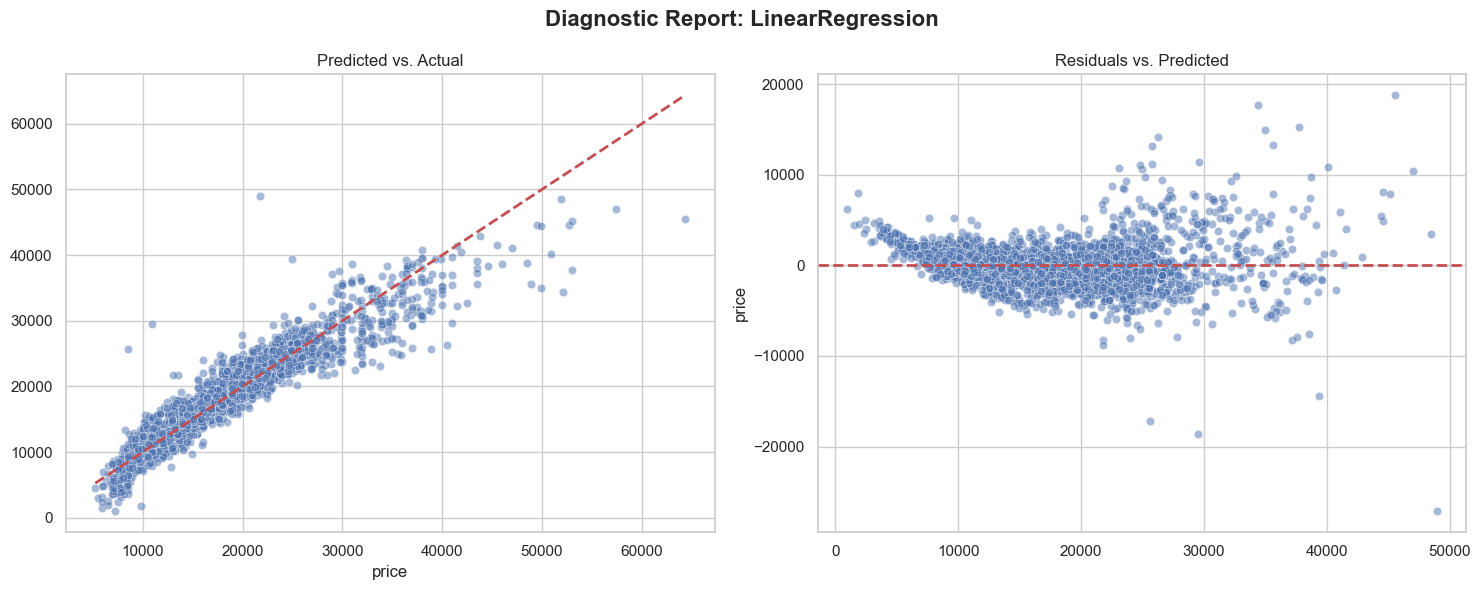

Saved model to saved_models\LinearRegression_157_features.joblib
Logged LinearRegression (157 features) to model_results.csv
                          9
model      LinearRegression
features                157
train_r2              0.896
test_r2              0.8903
test_mae          1660.1408
test_rmse         2432.4521
test_mape           10.0941


In [13]:
model_results(ols_model, X_train, y_train, X_test, y_test)

No evidence of overfitting, thus Ridge and Lasso regression will no be used.

### Random Forest

In [14]:
rf_pipe = Pipeline([ 
    ('rf', RandomForestRegressor(random_state=42))
])

def rf_space(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_features': trial.suggest_float('max_features', 0.1, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_samples': trial.suggest_float('max_samples', 0.5, 1.0)
    }

rf_model, rf_study = tune_and_fit_model(rf_pipe, rf_space, X_train, y_train)

Best Validation R2 Score: 0.9476

Best Hyperparameters:
n_estimators: 736
max_features: 0.4166
max_depth: 17
min_samples_split: 2
min_samples_leaf: 3
max_samples: 0.6584


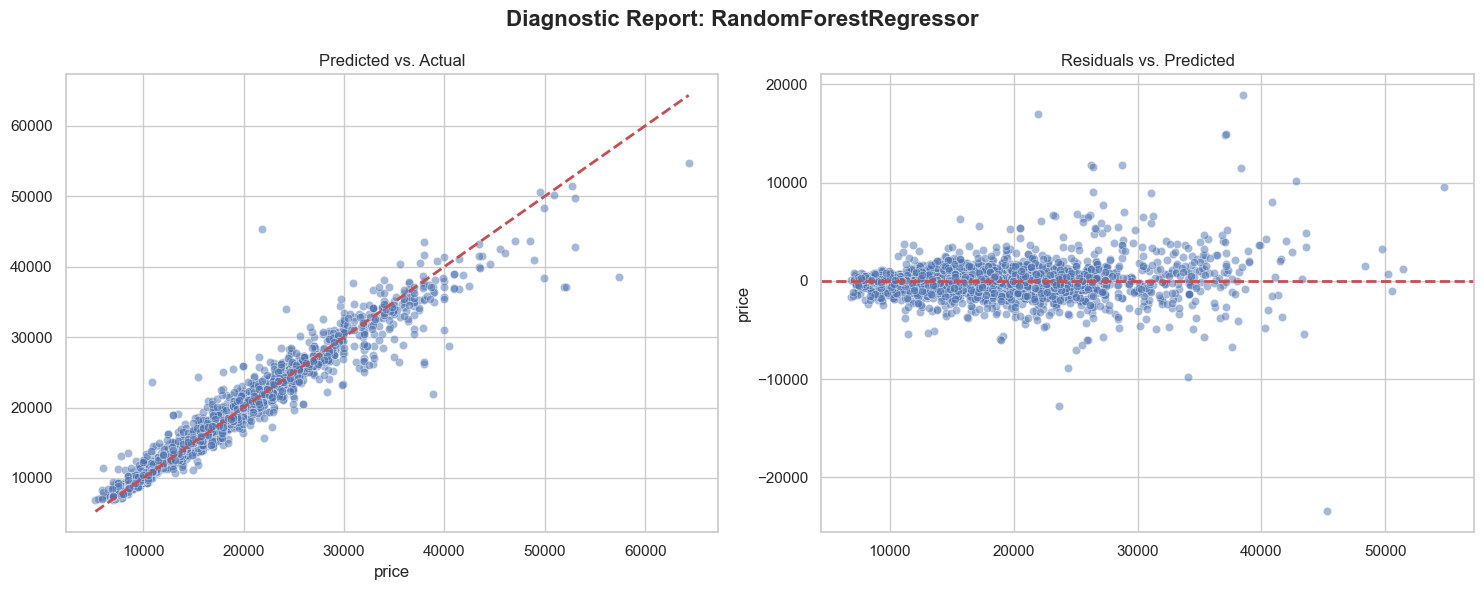

Saved model to saved_models\RandomForestRegressor_157_features.joblib
Logged RandomForestRegressor (157 features) to model_results.csv
                               9
model      RandomForestRegressor
features                     157
train_r2                  0.9763
test_r2                   0.9509
test_mae                908.7064
test_rmse              1627.8046
test_mape                 5.0151


In [15]:
model_results(rf_model, X_train, y_train, X_test, y_test)

### XGBoost

In [16]:
xgb_pipe = Pipeline([ 
    ('xgb', XGBRegressor(random_state=42))
])

def xgb_space(trial):
    return {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0)
    }

xgb_model, xgb_study = tune_and_fit_model(xgb_pipe, xgb_space, X_train, y_train)

Best Validation R2 Score: 0.9586

Best Hyperparameters:
learning_rate: 0.0391
n_estimators: 683
max_depth: 8
min_child_weight: 3
subsample: 0.7344
colsample_bytree: 0.6879


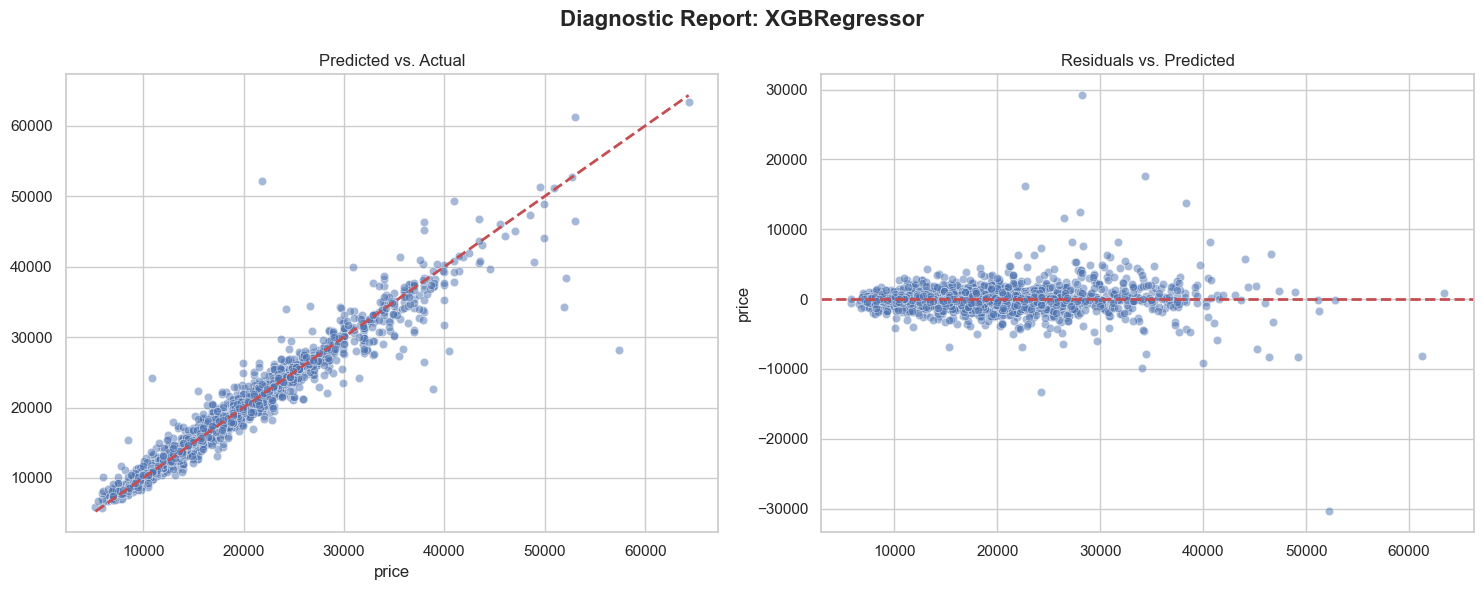

Saved model to saved_models\XGBRegressor_157_features.joblib
Logged XGBRegressor (157 features) to model_results.csv
                      9
model      XGBRegressor
features            157
train_r2         0.9962
test_r2          0.9534
test_mae        811.238
test_rmse     1585.3753
test_mape        4.4853


In [17]:
model_results(xgb_model, X_train, y_train, X_test, y_test)

### Gradient Boosting

In [18]:
gb_pipe = Pipeline([
    ('gb', GradientBoostingRegressor(random_state=42))
]) 

def gb_space(trial):
    return {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'max_features': trial.suggest_float('max_features', 0.1, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10)
    }

gb_model, gb_study = tune_and_fit_model(gb_pipe, gb_space, X_train, y_train)

Best Validation R2 Score: 0.9599

Best Hyperparameters:
learning_rate: 0.0256
n_estimators: 790
max_depth: 10
subsample: 0.7241
max_features: 0.3262
min_samples_split: 9
min_samples_leaf: 9


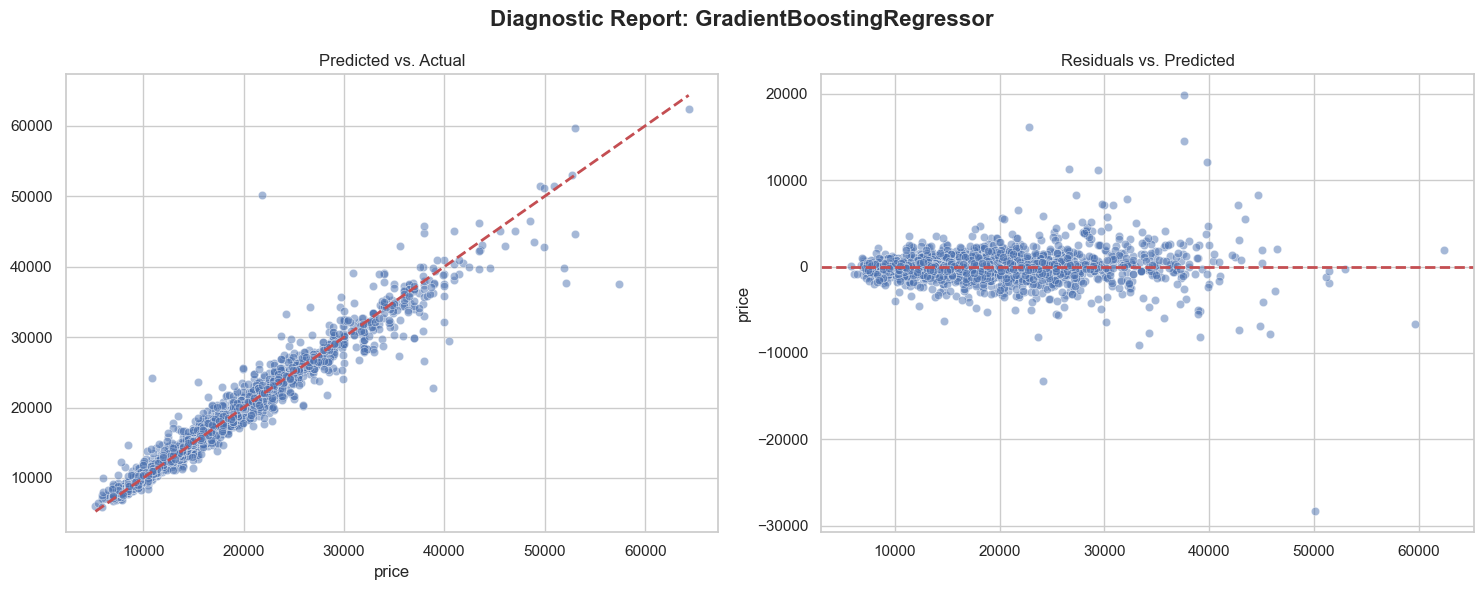

Saved model to saved_models\GradientBoostingRegressor_157_features.joblib
Logged GradientBoostingRegressor (157 features) to model_results.csv
                                   5                          9
model      GradientBoostingRegressor  GradientBoostingRegressor
features                           7                        157
train_r2                      0.9397                     0.9941
test_r2                        0.908                     0.9577
test_mae                   1360.4813                   816.5701
test_rmse                  2226.5265                  1510.6695
test_mape                      7.813                     4.5325


In [19]:
model_results(gb_model, X_train, y_train, X_test, y_test)

### LightGBM

In [20]:
lgbm_pipe = Pipeline([ 
    ('lgbm', LGBMRegressor(random_state=42, verbosity=-1)) 
])

def lgbm_space(trial):
    return {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0)
    }

lgbm_model, lgbm_study = tune_and_fit_model(lgbm_pipe, lgbm_space, X_train, y_train)

Best Validation R2 Score: 0.9584

Best Hyperparameters:
learning_rate: 0.1069
num_leaves: 90
n_estimators: 822
max_depth: 12
min_child_samples: 78
colsample_bytree: 0.6089


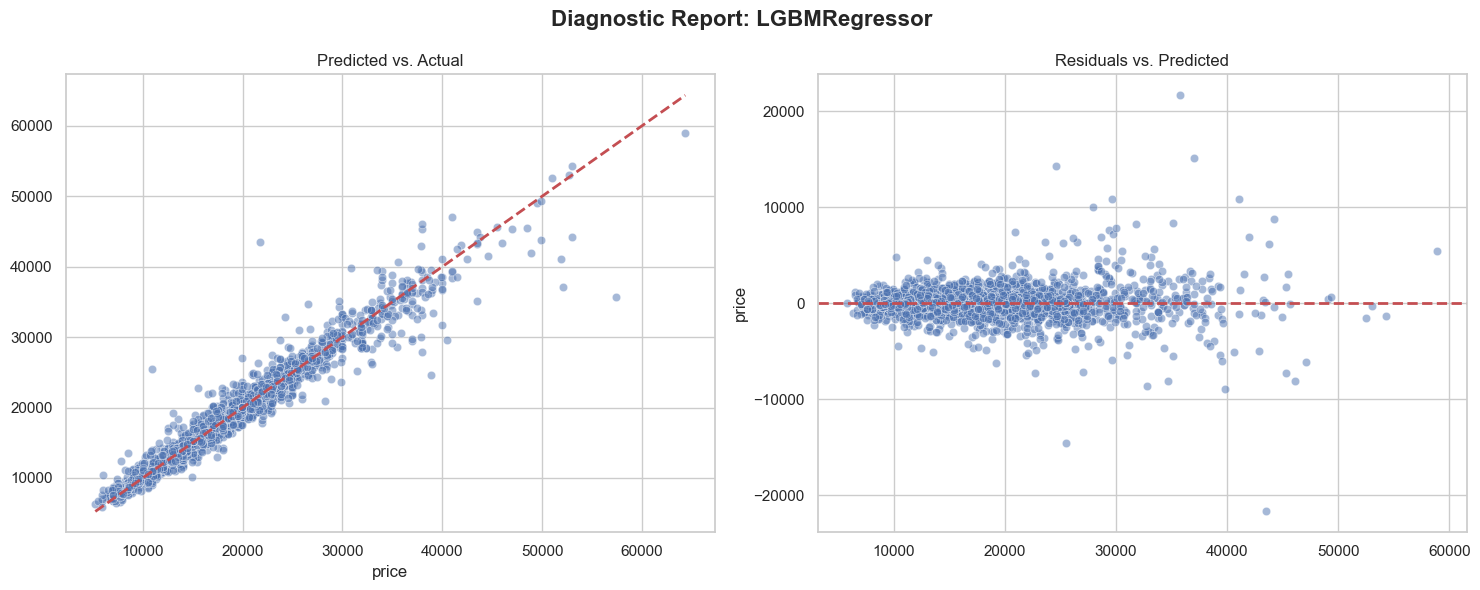

Saved model to saved_models\LGBMRegressor_157_features.joblib
Logged LGBMRegressor (157 features) to model_results.csv
                       3              9
model      LGBMRegressor  LGBMRegressor
features               9            157
train_r2          0.9517         0.9936
test_r2           0.9124         0.9564
test_mae       1201.8871       861.4685
test_rmse      2173.2348      1533.8636
test_mape         6.5709         4.7866


In [21]:
model_results(lgbm_model, X_train, y_train, X_test, y_test)

### Catboost

In [22]:
cat_pipe = Pipeline([ 
    ('cat', CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False)) 
])

def cat_space(trial):
    return {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'border_count': trial.suggest_int('border_count', 32, 255)
    }

cat_model, cat_study = tune_and_fit_model(cat_pipe, cat_space, X_train, y_train)

Best Validation R2 Score: 0.9587

Best Hyperparameters:
learning_rate: 0.1317
iterations: 540
depth: 9
l2_leaf_reg: 0.1428
random_strength: 0.0008
bagging_temperature: 0.0017
border_count: 108


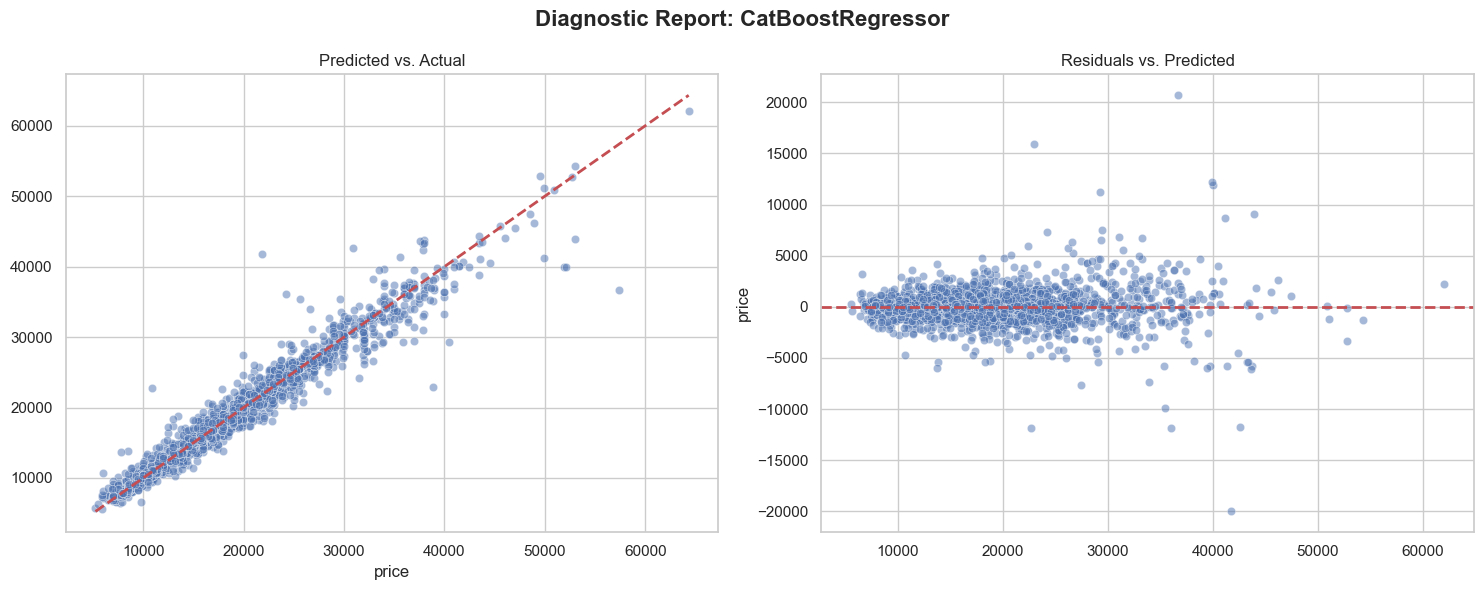

Saved model to saved_models\CatBoostRegressor_157_features.joblib
Logged CatBoostRegressor (157 features) to model_results.csv
                           1                  9
model      CatBoostRegressor  CatBoostRegressor
features                   8                157
train_r2              0.9676             0.9976
test_r2               0.9207             0.9594
test_mae           1156.3256           826.6308
test_rmse          2068.1005          1478.6383
test_mape             6.3576             4.6141


In [23]:
model_results(cat_model, X_train, y_train, X_test, y_test)

### Performance Table

In [24]:
results = pd.read_csv('model_results.csv')

results[results['features'] == X_test.shape[1]].sort_values(by='test_r2', ascending=False)

,model,features,train_r2,test_r2,test_mae,test_rmse,test_mape
8,CatBoostRegressor,157,0.9976,0.9594,826.6308,1478.6383,4.6141
6,GradientBoostingRegressor,157,0.9941,0.9577,816.5701,1510.6695,4.5325
7,LGBMRegressor,157,0.9936,0.9564,861.4685,1533.8636,4.7866
5,XGBRegressor,157,0.9962,0.9534,811.2380,1585.3753,4.4853
4,RandomForestRegressor,157,0.9763,0.9509,908.7064,1627.8046,5.0151
3,LinearRegression,157,0.8960,0.8903,1660.1408,2432.4521,10.0941


## Reduced Features

Top three models

### Catboost

In [25]:
# CatBoost
cat_importance = get_pipeline_importance('saved_models/CatBoostRegressor_157_features.joblib', X_test)
cat_importance.head(13)

,Feature,Importance,Cumulative_Importance
0,age_years,1763.953341,0.139415
1,hp_kw,1717.763502,0.275179
2,km,1038.803979,0.357282
3,gearing_type_manual,978.503056,0.434618
4,make_model_audi_a3,798.027613,0.497691
5,gears,487.511524,0.536222
6,make_model_renault_espace,422.968951,0.569651
7,weight_kg,350.834537,0.597380
8,make_model_renault_clio,307.251023,0.621663
9,make_model_opel_insignia,275.594039,0.643445


In [26]:
top_cat_features = cat_importance[cat_importance['Cumulative_Importance'] <= 0.60]['Feature'].tolist()

X_train_cat = X_train[top_cat_features]
X_test_cat = X_test[top_cat_features]

In [27]:
cat_pipe = Pipeline([ 
    ('cat', CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False)) 
])

def cat_space(trial):
    return {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'border_count': trial.suggest_int('border_count', 32, 255)
    }

cat_model, cat_study = tune_and_fit_model(cat_pipe, cat_space, X_train_cat, y_train)

Best Validation R2 Score: 0.9341

Best Hyperparameters:
learning_rate: 0.2886
iterations: 599
depth: 6
l2_leaf_reg: 3.8479
random_strength: 0.002
bagging_temperature: 0.4361
border_count: 190


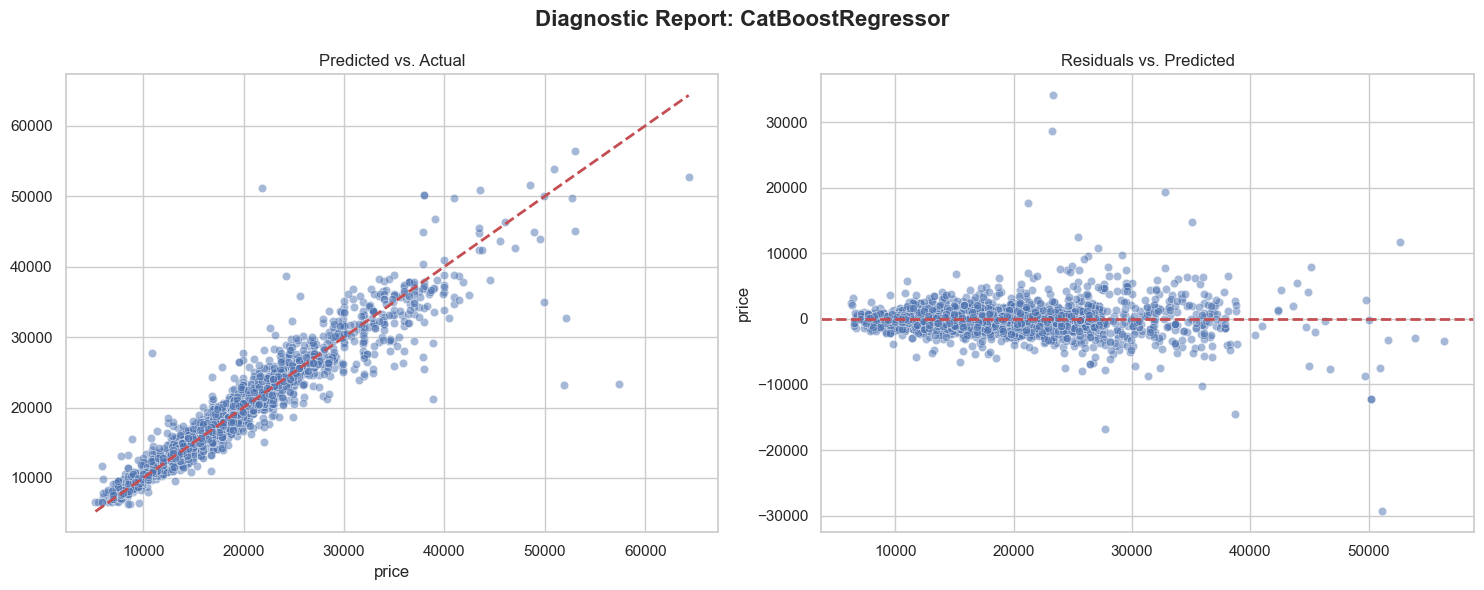

Saved model to saved_models\CatBoostRegressor_8_features.joblib
Logged CatBoostRegressor (8 features) to model_results.csv
                           8                  9
model      CatBoostRegressor  CatBoostRegressor
features                 157                  8
train_r2              0.9976             0.9676
test_r2               0.9594             0.9207
test_mae            826.6308          1156.3256
test_rmse          1478.6383          2068.1005
test_mape             4.6141             6.3576


In [28]:
model_results(cat_model, X_train_cat, y_train, X_test_cat, y_test)

### LightGBM	

In [29]:
lgbm_importance = get_pipeline_importance("saved_models/LGBMRegressor_157_features.joblib", X_test).head(12)
lgbm_importance

,Feature,Importance,Cumulative_Importance
0,hp_kw,2222.588637,0.170362
1,age_years,1574.782022,0.291070
2,km,1071.970995,0.373236
3,gearing_type_manual,703.837792,0.427186
4,make_model_renault_espace,600.910259,0.473246
5,make_model_audi_a3,519.405641,0.513058
6,gears,485.943395,0.550306
7,make_model_opel_corsa,306.889010,0.573829
8,make_model_opel_astra,275.122431,0.594917
9,make_model_opel_insignia,245.592732,0.613742


In [30]:
top_lgbm_features = lgbm_importance[lgbm_importance['Cumulative_Importance'] <= 0.60]['Feature'].tolist()

X_train_lgbm = X_train[top_lgbm_features]
X_test_lgbm = X_test[top_lgbm_features]

In [31]:
lgbm_pipe = Pipeline([ 
    ('lgbm', LGBMRegressor(random_state=42, verbosity=-1)) 
])

def lgbm_space(trial):
    return {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0)
    }

lgbm_model, lgbm_study = tune_and_fit_model(lgbm_pipe, lgbm_space, X_train_lgbm, y_train, n_trials=10, seed=42)

Best Validation R2 Score: 0.9213

Best Hyperparameters:
learning_rate: 0.0122
num_leaves: 133
n_estimators: 641
max_depth: 12
min_child_samples: 6
colsample_bytree: 0.985


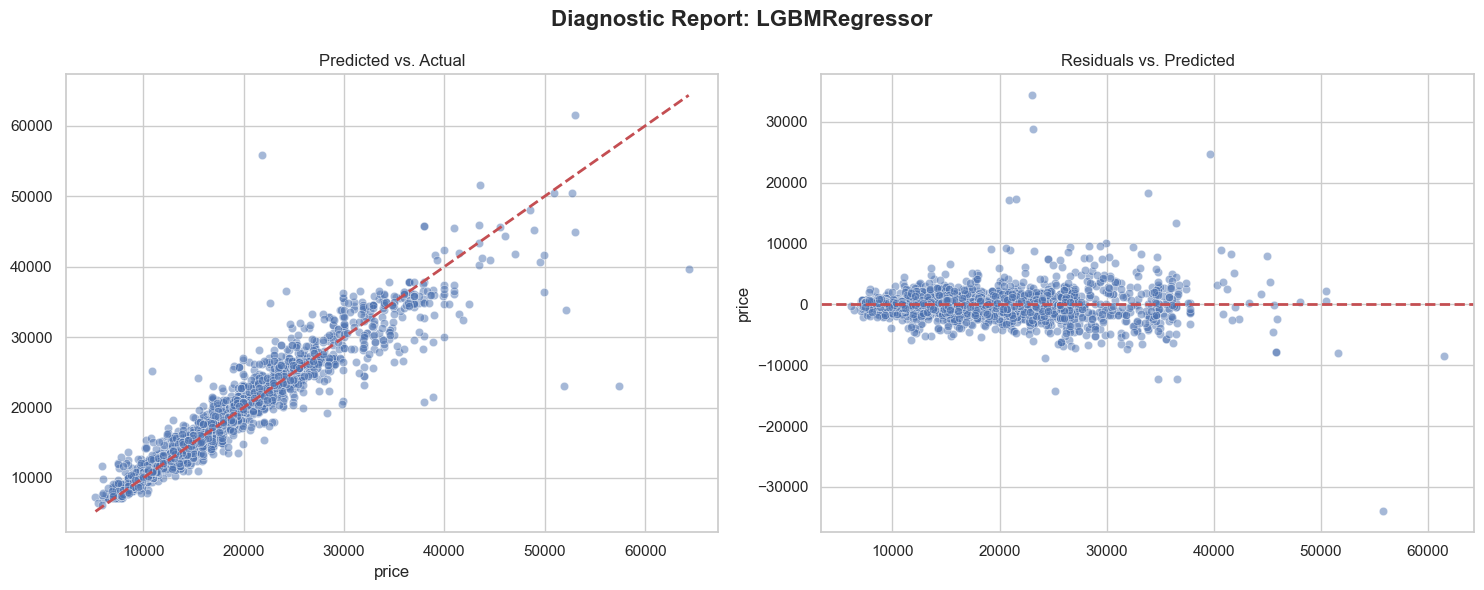

Saved model to saved_models\LGBMRegressor_9_features.joblib
Logged LGBMRegressor (9 features) to model_results.csv
                       6              9
model      LGBMRegressor  LGBMRegressor
features             157              9
train_r2          0.9936         0.9517
test_r2           0.9564         0.9124
test_mae        861.4685      1201.8871
test_rmse      1533.8636      2173.2348
test_mape         4.7866         6.5709


In [32]:
model_results(lgbm_model, X_train_lgbm, y_train, X_test_lgbm, y_test)

### Gradient Boosting

In [33]:
gb_importance = get_pipeline_importance("saved_models/GradientBoostingRegressor_157_features.joblib", X_test).head(12)
gb_importance

,Feature,Importance,Cumulative_Importance
0,hp_kw,2026.423324,0.168452
1,age_years,1511.161693,0.294071
2,km,950.786454,0.373108
3,gearing_type_manual,822.766226,0.441503
4,gears,727.587125,0.501986
5,make_model_audi_a3,457.578111,0.540023
6,make_model_renault_espace,414.441893,0.574475
7,weight_kg,361.510378,0.604526
8,next_inspection_yyyymm,305.429233,0.629916
9,make_model_opel_astra,299.967341,0.654851


In [34]:
top_gb_features = gb_importance[gb_importance['Cumulative_Importance'] <= 0.60]['Feature'].tolist()

X_train_gb = X_train[top_gb_features]
X_test_gb = X_test[top_gb_features]

In [35]:
gb_pipe = Pipeline([
    ('gb', GradientBoostingRegressor(random_state=42))
]) 

def gb_space(trial):
    return {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'max_features': trial.suggest_float('max_features', 0.1, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10)
    }

gb_model, gb_study = tune_and_fit_model(gb_pipe, gb_space, X_train_gb, y_train, n_trials=10, seed=42)

Best Validation R2 Score: 0.9072

Best Hyperparameters:
learning_rate: 0.0336
n_estimators: 353
max_depth: 10
subsample: 0.5705
max_features: 0.822
min_samples_split: 3
min_samples_leaf: 10


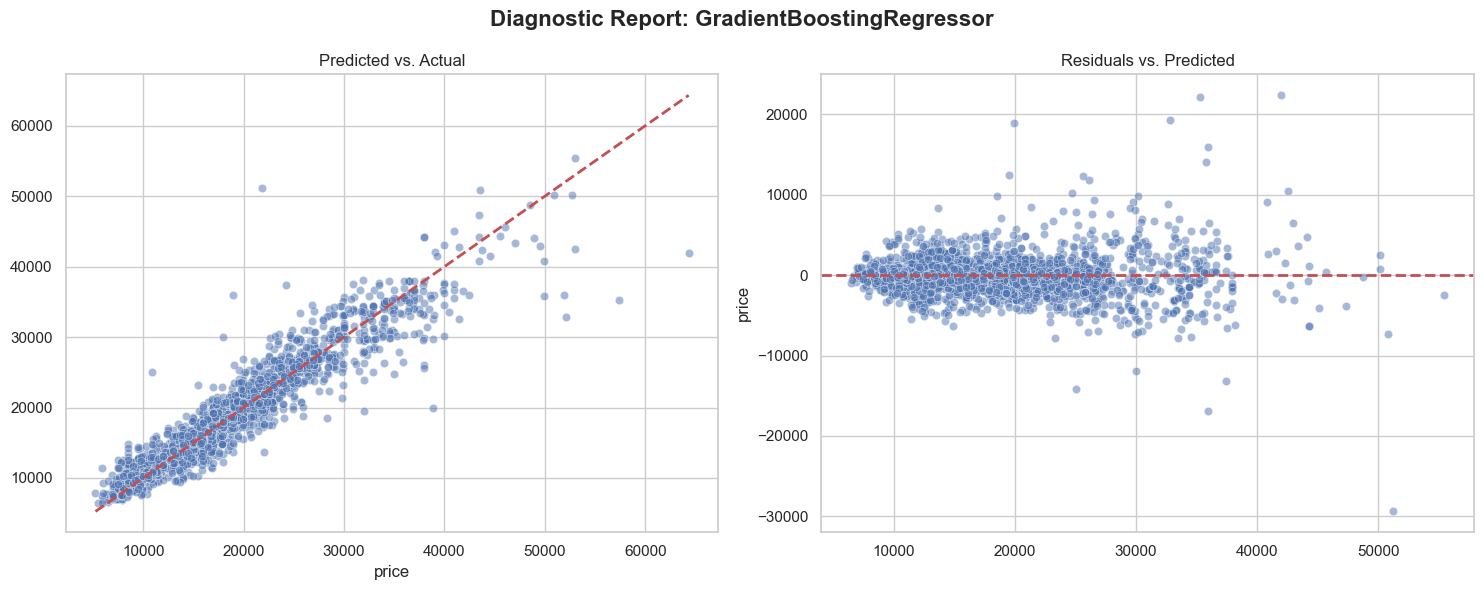

Saved model to saved_models\GradientBoostingRegressor_7_features.joblib
Logged GradientBoostingRegressor (7 features) to model_results.csv
                                   4                          9
model      GradientBoostingRegressor  GradientBoostingRegressor
features                         157                          7
train_r2                      0.9941                     0.9397
test_r2                       0.9577                      0.908
test_mae                    816.5701                  1360.4813
test_rmse                  1510.6695                  2226.5265
test_mape                     4.5325                      7.813


In [36]:
model_results(gb_model, X_train_gb, y_train, X_test_gb, y_test)

### Performance Table

In [37]:
results = pd.read_csv('model_results.csv')

results.sort_values(by='test_r2', ascending=False)

,model,features,train_r2,test_r2,test_mae,test_rmse,test_mape
5,CatBoostRegressor,157,0.9976,0.9594,826.6308,1478.6383,4.6141
3,GradientBoostingRegressor,157,0.9941,0.9577,816.5701,1510.6695,4.5325
4,LGBMRegressor,157,0.9936,0.9564,861.4685,1533.8636,4.7866
2,XGBRegressor,157,0.9962,0.9534,811.2380,1585.3753,4.4853
1,RandomForestRegressor,157,0.9763,0.9509,908.7064,1627.8046,5.0151
6,CatBoostRegressor,8,0.9676,0.9207,1156.3256,2068.1005,6.3576
7,LGBMRegressor,9,0.9517,0.9124,1201.8871,2173.2348,6.5709
8,GradientBoostingRegressor,7,0.9397,0.9080,1360.4813,2226.5265,7.8130
0,LinearRegression,157,0.8960,0.8903,1660.1408,2432.4521,10.0941
